# 从零实现 Byte-Level BPE 分词器

**目标**: 深入理解 GPT-2 采用的 byte-level BPE 分词算法

**核心思路**:
1. 所有文本先转为 UTF-8 字节序列（初始词表 = 256 个字节）
2. 反复找出最高频的相邻字节对，合并为新 token
3. 直到词表达到目标大小

这种方法天然支持任何语言，无需预处理 Unicode。

## 1. UTF-8 字节基础

中文和英文在 UTF-8 下的字节长度差异很大：英文字母 1 字节，中文汉字 3 字节。

In [1]:
# 观察不同文字的 UTF-8 字节表示
for char in ["A", "z", " ", "你", "好", "🌍"]:
    b = char.encode("utf-8")
    print(f"  '{char}'  →  {len(b)} 字节  →  {list(b)}")

  'A'  →  1 字节  →  [65]
  'z'  →  1 字节  →  [122]
  ' '  →  1 字节  →  [32]
  '你'  →  3 字节  →  [228, 189, 160]
  '好'  →  3 字节  →  [229, 165, 189]
  '🌍'  →  4 字节  →  [240, 159, 140, 141]


## 2. 加载语料 + 转字节序列

In [2]:
import os

corpus_path = os.path.join("data", "corpus.txt")
with open(corpus_path, "r", encoding="utf-8") as f:
    text = f.read()

raw_bytes = text.encode("utf-8")
print(f"语料字符数: {len(text):,}")
print(f"UTF-8 字节数: {len(raw_bytes):,}")
print(f"前 200 字符预览:\n{text[:200]}")

语料字符数: 1,115,394
UTF-8 字节数: 1,115,394
前 200 字符预览:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 3. 统计 pair 频率

在合并之前，先看看原始字节序列中哪些相邻 pair 最常见。

In [3]:
from bpe_tokenizer import _count_pairs

ids = list(raw_bytes)
counts = _count_pairs(ids)

# Top-10 最常见的 pair
top10 = sorted(counts.items(), key=lambda x: -x[1])[:10]
print("Top-10 相邻字节 pair:")
for pair, freq in top10:
    # 尝试解码这个 pair 对应的字节
    pair_bytes = bytes([pair[0], pair[1]])
    try:
        readable = pair_bytes.decode("utf-8")
    except UnicodeDecodeError:
        readable = str(pair_bytes)
    print(f"  {pair}  freq={freq:>6,}  bytes={pair_bytes!r:>12}  text={readable!r}")

Top-10 相邻字节 pair:
  (101, 32)  freq=27,643  bytes=       b'e '  text='e '
  (32, 116)  freq=23,837  bytes=       b' t'  text=' t'
  (116, 104)  freq=22,739  bytes=       b'th'  text='th'
  (104, 101)  freq=18,203  bytes=       b'he'  text='he'
  (116, 32)  freq=16,508  bytes=       b't '  text='t '
  (115, 32)  freq=15,364  bytes=       b's '  text='s '
  (100, 32)  freq=14,165  bytes=       b'd '  text='d '
  (44, 32)  freq=14,098  bytes=       b', '  text=', '
  (32, 97)  freq=13,541  bytes=       b' a'  text=' a'
  (111, 117)  freq=12,730  bytes=       b'ou'  text='ou'


## 4. 手动合并一次

取最高频 pair，执行一次合并，观察序列变化。

In [4]:
from bpe_tokenizer import _merge

best_pair = max(counts, key=counts.get)
print(f"最高频 pair: {best_pair}, 出现 {counts[best_pair]:,} 次")

# 合并前
print(f"\n合并前序列长度: {len(ids):,}")

# 执行合并: 新 token id = 256
ids_after = _merge(ids, best_pair, 256)
print(f"合并后序列长度: {len(ids_after):,}")
print(f"减少了 {len(ids) - len(ids_after):,} 个元素")

# 展示合并前后的一小段
sample_start = 0
sample_len = 50
print(f"\n合并前 (前{sample_len}): {ids[sample_start:sample_start+sample_len]}")
print(f"合并后 (前{sample_len}): {ids_after[sample_start:sample_start+sample_len]}")

最高频 pair: (101, 32), 出现 27,643 次

合并前序列长度: 1,115,394
合并后序列长度: 1,087,751
减少了 27,643 个元素

合并前 (前50): [70, 105, 114, 115, 116, 32, 67, 105, 116, 105, 122, 101, 110, 58, 10, 66, 101, 102, 111, 114, 101, 32, 119, 101, 32, 112, 114, 111, 99, 101, 101, 100, 32, 97, 110, 121, 32, 102, 117, 114, 116, 104, 101, 114, 44, 32, 104, 101, 97, 114]
合并后 (前50): [70, 105, 114, 115, 116, 32, 67, 105, 116, 105, 122, 101, 110, 58, 10, 66, 101, 102, 111, 114, 256, 119, 256, 112, 114, 111, 99, 101, 101, 100, 32, 97, 110, 121, 32, 102, 117, 114, 116, 104, 101, 114, 44, 32, 104, 101, 97, 114, 32, 109]


## 5. 完整训练

使用 `ByteLevelBPETokenizer` 在语料上训练，目标词表 1256（256 基础 + 1000 次合并）。

In [5]:
from bpe_tokenizer import ByteLevelBPETokenizer

tok = ByteLevelBPETokenizer()
tok.train(text, vocab_size=1256, verbose=True)

原始字节长度: 1,115,394
  合并 #   0: (101, 32) → 256  freq=27,643  token='e '  序列长度=1,087,751
  合并 #   1: (116, 104) → 257  freq=22,739  token='th'  序列长度=1,065,012
  合并 #   2: (116, 32) → 258  freq=16,508  token='t '  序列长度=1,048,504
  合并 #   3: (115, 32) → 259  freq=15,364  token='s '  序列长度=1,033,140
  合并 #   4: (100, 32) → 260  freq=14,165  token='d '  序列长度=1,018,975
  合并 #   5: (44, 32) → 261  freq=14,098  token=', '  序列长度=1,004,877
  合并 #   6: (111, 117) → 262  freq=12,730  token='ou'  序列长度=992,147
  合并 #   7: (101, 114) → 263  freq=11,771  token='er'  序列长度=980,376
  合并 #   8: (105, 110) → 264  freq=10,606  token='in'  序列长度=969,770
  合并 #   9: (121, 32) → 265  freq=10,283  token='y '  序列长度=959,487
  合并 #  10: (97, 110) → 266  freq=10,197  token='an'  序列长度=949,290
  合并 #  11: (58, 10) → 267  freq=8,762  token=':\n'  序列长度=940,528
  合并 #  12: (111, 114) → 268  freq=8,458  token='or'  序列长度=932,070
  合并 #  13: (111, 32) → 269  freq=8,134  token='o '  序列长度=923,936
  合并 #  14: (101, 110) → 270  f

### 压缩比曲线

观察随着合并次数增加，序列长度如何下降。

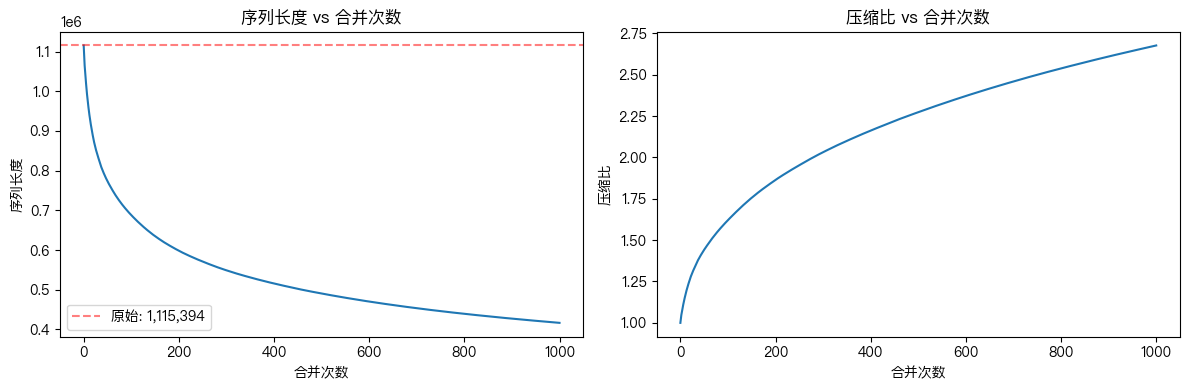

最终压缩比: 2.68x


In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置中文字体（macOS）
mpl.rcParams["font.sans-serif"] = ["PingFang HK", "Hiragino Sans GB", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False  # 正常显示负号

# 重新训练，记录每步的序列长度
tok2 = ByteLevelBPETokenizer()
raw_ids = list(text.encode("utf-8"))
original_len = len(raw_ids)

lengths = [original_len]
ids_track = raw_ids[:]

for i in range(1000):
    counts = _count_pairs(ids_track)
    if not counts:
        break
    best = max(counts, key=counts.get)
    new_id = 256 + i
    ids_track = _merge(ids_track, best, new_id)
    lengths.append(len(ids_track))

# 绘制压缩比曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lengths)
ax1.set_xlabel("合并次数")
ax1.set_ylabel("序列长度")
ax1.set_title("序列长度 vs 合并次数")
ax1.axhline(y=original_len, color="r", linestyle="--", alpha=0.5, label=f"原始: {original_len:,}")
ax1.legend()

ratios = [original_len / l for l in lengths]
ax2.plot(ratios)
ax2.set_xlabel("合并次数")
ax2.set_ylabel("压缩比")
ax2.set_title("压缩比 vs 合并次数")

plt.tight_layout()
plt.show()
print(f"最终压缩比: {ratios[-1]:.2f}x")

## 6. Encode / Decode 往返一致性测试

In [7]:
test_cases = [
    "",
    "hello world",
    "你好世界",
    "Hello, 世界! 🌍",
    "大语言模型是一种基于深度学习的自然语言处理技术。",
    "To be, or not to be, that is the question.",
    "混合 mixed 文本 text 测试 test",
]

print("往返一致性测试 (decode(encode(x)) == x):\n")
all_pass = True
for t in test_cases:
    ids = tok.encode(t)
    decoded = tok.decode(ids)
    ok = decoded == t
    all_pass = all_pass and ok
    status = "PASS" if ok else "FAIL"
    print(f"  [{status}] {t!r}")
    print(f"         → {len(ids)} tokens, 压缩比 {len(t.encode('utf-8'))/max(len(ids),1):.1f}x")

print(f"\n{'全部通过!' if all_pass else '有测试失败!'}")

往返一致性测试 (decode(encode(x)) == x):

  [PASS] ''
         → 0 tokens, 压缩比 0.0x
  [PASS] 'hello world'
         → 6 tokens, 压缩比 1.8x
  [PASS] '你好世界'
         → 12 tokens, 压缩比 1.0x
  [PASS] 'Hello, 世界! 🌍'
         → 14 tokens, 压缩比 1.4x
  [PASS] '大语言模型是一种基于深度学习的自然语言处理技术。'
         → 72 tokens, 压缩比 1.0x
  [PASS] 'To be, or not to be, that is the question.'
         → 14 tokens, 压缩比 3.0x
  [PASS] '混合 mixed 文本 text 测试 test'
         → 27 tokens, 压缩比 1.3x

全部通过!


## 7. 词表分析

看看 BPE 学到了哪些 token — 常见汉字和英文词应该被合并为单个 token。

In [8]:
# 按 token 字节长度排序，展示学到的 top-50 最长 token
learned_tokens = []
for tid, tbytes in tok.vocab.items():
    if tid >= 256:  # 只看合并产生的 token
        try:
            readable = tbytes.decode("utf-8")
        except UnicodeDecodeError:
            readable = None
        learned_tokens.append((tid, tbytes, readable))

# 按字节长度降序
learned_tokens.sort(key=lambda x: -len(x[1]))

print("Top-50 学到的 token（按长度排序）:\n")
print(f"{'ID':>6}  {'长度':>4}  {'内容'}")
print("-" * 50)
for tid, tbytes, readable in learned_tokens[:50]:
    display = readable if readable else tbytes.hex()
    print(f"{tid:>6}  {len(tbytes):>4}  {display!r}")

Top-50 学到的 token（按长度排序）:

    ID    长度  内容
--------------------------------------------------
  1069    19  '.\n\nDUKE VINCENTIO:\n'
   983    17  '.\n\nKING RICHARD I'
   833    16  'DUKE VINCENTIO:\n'
  1041    15  '.\n\nGLOUCESTER:\n'
  1226    15  'QUEEN ELIZABETH'
  1212    14  '.\n\nPETRUCHIO:\n'
  1225    14  'QUEEN ELIZABET'
  1241    13  '.\n\nMENENIUS:\n'
  1224    12  'QUEEN ELIZAB'
   742    11  'LOUCESTER:\n'
   778    11  'VINCENTIO:\n'
   977    11  'ORIOLANUS:\n'
   938    10  'ETRUCHIO:\n'
  1065    10  'ISABELLA:\n'
  1223    10  'QUEEN ELIZ'
   725     9  'RICHARD I'
   926     9  'ENENIUS:\n'
   994     9  '.\n\nFirst '
  1055     9  'OF YORK:\n'
  1134     9  'ICINIUS:\n'
  1177     9  'EDWARD IV'
  1222     9  'QUEEN ELI'
   674     8  '.\n\nKING '
  1081     8  ' should '
  1086     8  'JULIET:\n'
  1088     8  'EONTES:\n'
  1095     8  'entleman'
  1138     8  'I would '
  1176     8  'EDWARD I'
  1184     8  'for the '
  1213     8  ' to the '
  1221     8  'QU

In [9]:
# 统计可解码为完整中文字符的 token
chinese_tokens = [(tid, r) for tid, _, r in learned_tokens if r and any('\u4e00' <= c <= '\u9fff' for c in r)]
print(f"包含中文的 token 数量: {len(chinese_tokens)}\n")
print("示例:")
for tid, readable in chinese_tokens[:30]:
    print(f"  {tid:>6}  {readable!r}")

包含中文的 token 数量: 0

示例:


## 8. （可选）与 tiktoken 对比

如果安装了 tiktoken，可以对比我们的 BPE 和 GPT-4 的分词结果。

In [10]:
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")

    compare_texts = [
        "Hello, world!",
        "你好世界",
        "大语言模型是一种基于深度学习的自然语言处理技术。",
        "To be, or not to be.",
    ]

    print(f"{'文本':<30} {'我们的BPE':>10} {'tiktoken':>10}")
    print("-" * 55)
    for t in compare_texts:
        our_len = len(tok.encode(t))
        tk_len = len(enc.encode(t))
        print(f"{t:<30} {our_len:>10} {tk_len:>10}")

    print(f"\n注意: tiktoken 词表 ~100k，我们只有 1256，所以 token 数更多是正常的。")
except ImportError:
    print("tiktoken 未安装，跳过对比。")
    print("安装: uv pip install tiktoken")

文本                                 我们的BPE   tiktoken
-------------------------------------------------------
Hello, world!                           7          4
你好世界                                   12          5
大语言模型是一种基于深度学习的自然语言处理技术。               72         26
To be, or not to be.                    8          8

注意: tiktoken 词表 ~100k，我们只有 1256，所以 token 数更多是正常的。


## 9. 保存模型

将训练好的分词器保存到文件，以便后续复用。

In [11]:
model_path = os.path.join("data", "bpe_model.json")
tok.save(model_path)
print(f"模型已保存到: {model_path}")
print(f"文件大小: {os.path.getsize(model_path) / 1024:.1f} KB")

# 验证加载后仍然正确
tok_loaded = ByteLevelBPETokenizer()
tok_loaded.load(model_path)

test = "Hello, 世界! 验证加载后的分词器"
assert tok_loaded.decode(tok_loaded.encode(test)) == test
print(f"加载验证通过: {test!r}")

模型已保存到: data/bpe_model.json
文件大小: 81.0 KB
加载验证通过: 'Hello, 世界! 验证加载后的分词器'
